# ======================================================================
# MODULE 7: Quality Benchmarking & Thesis Results
# ======================================================================
#
# **Project:** QVSC — Quantum-assisted Video Steganographic Communication
#
# **Author:** Hasibul Hasan (Roll: 2003127, CSE, RUET)
#
# **Purpose:** Quantify the imperceptibility, robustness, and end-to-end
# integrity of the QVSC pipeline. This is the module that generates the
# headline results tables and figures for the thesis — PSNR, SSIM, BER,
# capacity, and decryption-success rate across multiple H.264 compression
# levels (constant QP 18, 23, 28, 35).
#
# **Why this module is essential to the thesis:**
# Modules 1–6 prove the pipeline *can* work end-to-end. Module 7 proves
# *how well* it works by running rigorous quantitative comparisons
# against the published QSAC baseline (Elsevier 2025) and the standard
# benchmarks expected by reviewers in steganography literature.
#
# **Three classes of metrics:**
#   1. **Imperceptibility** — Can a human (or detector) tell the stego
#      video from the cover? Measured by PSNR (≥35 dB target) and
#      SSIM (≥0.95 target).
#   2. **Robustness** — Does the payload survive lossy compression?
#      Measured by raw channel BER (near-zero at QP ≤ 23; any residual
#      errors are corrected by the Reed-Solomon FEC layer).
#   3. **Integrity** — Does the AEAD layer reject any tampering?
#      Measured by Poly1305 verification success/failure across
#      compression levels.
#
# **Input:**
# - `embedding_metadata.npy`  — From Module 4 (sender-side stats)
# - `extraction_report.npy`   — From Module 5 (receiver-side stats)
# - `decryption_report.npy`   — From Module 6 (verification outcome)
# - `cover_video.mp4`         — Original cover video
# - `roi_masks.npy`           — From Module 3 (for re-runs)
# - `fec_payload.bin`         — FEC-protected payload (for re-runs)
# - `quantum_key.bin`         — From Module 1 (for re-runs)
#
# **Output:**
# - `benchmark_results.csv`     — Full results table for thesis
# - `benchmark_results.npy`     — Same data in NumPy dict form
# - `figure_psnr_ssim.png`      — Imperceptibility plot
# - `figure_ber_vs_qp.png`      — Robustness plot
# - `figure_capacity.png`       — Payload capacity vs ROI threshold
# - `figure_quality_grid.png`   — Visual cover-vs-stego comparison
# - `thesis_results_table.md`   — Markdown table ready to paste
#
# **Algorithm:**
# ```
# 1. Load reports from Modules 4, 5, 6 (single-QP result already computed)
# 2. Re-run Modules 4 → 5 → 6 at additional QP values
# 3. Aggregate all metrics into a single results dict
# 4. Generate publication-quality plots
# 5. Export thesis-ready tables (CSV + Markdown)
# ```
#
# **Tools:** OpenCV, NumPy, SciPy, Matplotlib, Pandas, PyCryptodome
#
# **Dependency note:** This module imports the embed/extract/decrypt
# functions defined in Modules 4–6 by re-defining them here, so
# Module 7 runs as a standalone notebook without requiring Jupyter
# magic or %run.
#
# ======================================================================

## Section 1: Library Imports

In [1]:
import cv2
import numpy as np
from scipy.fft import dctn, idctn
import matplotlib.pyplot as plt
import pandas as pd
import os
import subprocess
import struct
import time
from Crypto.Cipher import ChaCha20_Poly1305
import fec_module as fec

# Display options
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 11
np.set_printoptions(suppress=True, precision=4)

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 2: Configuration

The benchmarking sweep tests how the pipeline behaves under different
H.264 compression strengths. We use a **constant quantization parameter
(QP)** rather than CRF: CRF rate-control varies the quantizer frame-to-
frame, which destroyed the embedded coefficient on every frame after the
first. Constant QP quantizes every frame identically, so the payload
survives uniformly — and QP is the right controlled variable for a
robustness study.

| QP | Quality | Use case |
|----|---------|----------|
| 18 | Near-lossless | High-bandwidth / archival |
| 23 | High quality (baseline) | Standard |
| 28 | Moderate compression | Lower bandwidth |
| 35 | Heavy compression | Stress test |

Lower QP = higher quality = larger files. The QVSC claim is that the
payload is recovered byte-exact (after FEC) through QP ≤ 23 with high
imperceptibility, degrading gracefully as QP rises until the residual
bit-error rate exceeds the Reed–Solomon correction budget.

In [2]:
# ── Inputs from previous modules ──────────────────────────────────────
COVER_VIDEO_PATH    = 'cover_video.mp4'
ROI_MASKS_FILE      = 'roi_masks.npy'
VIDEO_META_FILE     = 'video_metadata.npy'
CIPHERTEXT_FILE     = 'fec_payload.bin'   # FEC-protected payload (from Module 2 + FEC)
KEY_FILE            = 'quantum_key.bin'

# Reports from M4, M5, M6 (already exist for the baseline QP=23 run)
M4_META_FILE        = 'embedding_metadata.npy'
M5_REPORT_FILE      = 'extraction_report.npy'
M6_REPORT_FILE      = 'decryption_report.npy'

# ── Output paths ──────────────────────────────────────────────────────
RESULTS_CSV         = 'benchmark_results.csv'
RESULTS_NPY         = 'benchmark_results.npy'
RESULTS_MD          = 'thesis_results_table.md'

FIG_PSNR_SSIM       = 'figure_psnr_ssim.png'
FIG_BER_VS_QP       = 'figure_ber_vs_qp.png'
FIG_CAPACITY        = 'figure_capacity.png'
FIG_QUALITY_GRID    = 'figure_quality_grid.png'
FIG_DELTA_SWEEP     = 'figure_delta_sweep.png'
FIG_MASK_AGREE      = 'figure_mask_agreement.png'
FIG_FEC_HEADROOM    = 'figure_fec_headroom.png'

# ── Pipeline parameters (must match Module 4) ────────────────────────
BLOCK_SIZE          = 8
COEFF_POS           = (2, 2)   # low-frequency (compression-resilient)
QIM_DELTA           = 50
EMBED_CHANNEL       = 0        # Y (luminance)
MAX_EMBED_ITER      = 15       # informed-embedding passes
INTRA_ONLY          = True
H264_PRESET         = 'medium'
AAD                 = b"QVSC-Module2"

# ── Benchmarking sweep ────────────────────────────────────────────────
QP_VALUES           = [18, 23, 28, 35]    # Constant-QP levels to test
DELTA_SWEEP         = [30, 40, 50, 60, 70]  # centred on the Δ=50 baseline
RUN_FULL_SWEEP      = True   # If False, only loads existing reports

print("="*70)
print("  MODULE 7 CONFIGURATION (Benchmarking)")
print("="*70)
print(f"  QP values tested:     {QP_VALUES}")
print(f"  Δ values tested:      {DELTA_SWEEP}")
print(f"  Full sweep enabled:   {RUN_FULL_SWEEP}")
print(f"  Baseline params:      Δ={QIM_DELTA}, coeff={COEFF_POS}, block={BLOCK_SIZE}")
print("="*70)

  MODULE 7 CONFIGURATION (Benchmarking)
  QP values tested:     [18, 23, 28, 35]
  Δ values tested:      [30, 40, 50, 60, 70]
  Full sweep enabled:   True
  Baseline params:      Δ=50, coeff=(2, 2), block=8


## Section 3: Consolidated Pipeline Functions

We re-define the functions from Modules 3–6 inline so this notebook is
self-contained. **All function bodies are byte-identical to the
originals** — any change must be mirrored back to the parent module.

This consolidation is purely for benchmarking convenience; it doesn't
change the pipeline.

In [3]:
# ── From Module 3: ROI detection (block-level mask) ──────────────────
def detect_roi_blocks(frame_bgr, block_size=8, canny_low=50, canny_high=150,
                      blur_sigma=1.0, dilate_iterations=2, edge_threshold=0.30):
    """Identical to Module 5's detect_roi_blocks()."""
    ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
    y_channel = ycrcb[:, :, 0]
    y_blurred = cv2.GaussianBlur(y_channel, (5, 5), blur_sigma)
    edges = cv2.Canny(y_blurred, canny_low, canny_high)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges_dilated = cv2.dilate(edges, kernel, iterations=dilate_iterations)
    
    height, width = edges_dilated.shape
    blocks_y = height // block_size
    blocks_x = width  // block_size
    block_mask = np.zeros((blocks_y, blocks_x), dtype=np.uint8)
    pixels_per_block = block_size * block_size
    
    for by in range(blocks_y):
        for bx in range(blocks_x):
            y0 = by * block_size
            x0 = bx * block_size
            block = edges_dilated[y0:y0+block_size, x0:x0+block_size]
            if np.count_nonzero(block) / pixels_per_block > edge_threshold:
                block_mask[by, bx] = 1
    return block_mask


# ── From Module 4: DCT/QIM core ──────────────────────────────────────
def apply_dct_2d(block):
    return dctn(block, type=2, norm='ortho')

def apply_idct_2d(dct_block):
    return idctn(dct_block, type=2, norm='ortho')

def qim_embed_bit(coeff, bit, delta):
    quantized = delta * np.round(coeff / delta)
    return quantized + ((-1) ** (1 - bit)) * (delta / 4)

def qim_extract_bit(coeff, delta):
    quantized = delta * np.round(coeff / delta)
    return 1 if (coeff - quantized) > 0 else 0


print("Module 3-4 helper functions consolidated.")

Module 3-4 helper functions consolidated.


In [4]:
# ── From Module 4: Single-frame INFORMED embed / extract (Y channel) ──
def embed_in_frame(frame_bgr, block_mask, payload_bits, bit_index,
                   block_size=8, coeff_pos=(2, 2), delta=50, channel=0,
                   max_iter=15):
    """Informed DCT-QIM embedding (Y channel). After embedding, simulate the
    YCrCb<->BGR<->uint8 round-trip the extractor sees, find blocks that decode
    wrong, and pre-distort them until every block reads back correctly. Drives
    pre-compression BER to 0% — essential for the AEAD payload."""
    ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
    chan  = ycrcb[:, :, channel].astype(np.float64)
    by_n, bx_n = block_mask.shape
    u, v = coeff_pos
    asg = []
    for by in range(by_n):
        for bx in range(bx_n):
            if bit_index >= len(payload_bits): break
            if block_mask[by, bx] == 0: continue
            y0, x0 = by*block_size, bx*block_size
            D = apply_dct_2d(chan[y0:y0+block_size, x0:x0+block_size])
            b = int(payload_bits[bit_index])
            D[u, v] = qim_embed_bit(D[u, v], b, delta)
            chan[y0:y0+block_size, x0:x0+block_size] = np.clip(apply_idct_2d(D), 0, 255)
            asg.append((y0, x0, b)); bit_index += 1
        if bit_index >= len(payload_bits): break
    for _ in range(max_iter):
        ycrcb[:, :, channel] = np.round(np.clip(chan, 0, 255)).astype(np.uint8)
        rt = cv2.cvtColor(cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR),
                          cv2.COLOR_BGR2YCrCb)[:, :, channel].astype(np.float64)
        wrong = [(y0,x0,b) for (y0,x0,b) in asg
                 if qim_extract_bit(apply_dct_2d(rt[y0:y0+block_size, x0:x0+block_size])[u,v], delta) != b]
        if not wrong: break
        for (y0,x0,b) in wrong:
            obs = apply_dct_2d(rt[y0:y0+block_size, x0:x0+block_size])[u, v]
            q = delta*np.round(obs/delta); correct = q + (1 if b else -1)*(delta/4)
            Dw = apply_dct_2d(chan[y0:y0+block_size, x0:x0+block_size]); Dw[u,v] += (correct-obs)
            chan[y0:y0+block_size, x0:x0+block_size] = np.clip(apply_idct_2d(Dw), 0, 255)
    ycrcb[:, :, channel] = np.round(np.clip(chan, 0, 255)).astype(np.uint8)
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR), bit_index, len(asg)


def extract_from_frame(frame_bgr, block_mask, num_bits_to_extract,
                       block_size=8, coeff_pos=(2, 2), delta=50, channel=0):
    chan = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)[:, :, channel].astype(np.float64)
    by_n, bx_n = block_mask.shape
    out = []; u, v = coeff_pos
    for by in range(by_n):
        for bx in range(bx_n):
            if len(out) >= num_bits_to_extract: break
            if block_mask[by, bx] == 0: continue
            y0, x0 = by*block_size, bx*block_size
            out.append(qim_extract_bit(apply_dct_2d(chan[y0:y0+block_size, x0:x0+block_size])[u, v], delta))
        if len(out) >= num_bits_to_extract: break
    return out


def extract_video_frames(video_path, max_frames=None):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frames, count = [], 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        frames.append(frame); count += 1
        if max_frames and count >= max_frames: break
    cap.release()
    return frames, fps, width, height


In [5]:
# ── From Module 4: Quality metrics (PSNR / SSIM) ─────────────────────
def calculate_psnr(original, modified):
    """Peak Signal-to-Noise Ratio in dB. Higher = less distortion."""
    mse = np.mean((original.astype(np.float64) - modified.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(255.0 ** 2 / mse)


from skimage.metrics import structural_similarity as _ssim

def calculate_ssim(original, modified):
    """Proper windowed SSIM (11x11 Gaussian window, averaged) on full color.
    Far more sensitive to small localized changes than a single global SSIM."""
    return float(_ssim(original, modified, channel_axis=2, data_range=255))


# ── From Module 6: Decryption ─────────────────────────────────────────
def decrypt_chacha20_poly1305(key, nonce, ciphertext, tag, aad=b"QVSC-Module2"):
    cipher = ChaCha20_Poly1305.new(key=key, nonce=nonce)
    cipher.update(aad)
    return cipher.decrypt_and_verify(ciphertext, tag)


# ── Bit/byte utilities ────────────────────────────────────────────────
def bytes_to_bits(byte_data):
    bits = []
    for byte in byte_data:
        for bit_pos in range(7, -1, -1):
            bits.append((byte >> bit_pos) & 1)
    return np.array(bits, dtype=np.uint8)


def bits_to_bytes(bits):
    bits = np.asarray(bits, dtype=np.uint8)
    pad = (-len(bits)) % 8
    if pad:
        bits = np.concatenate([bits, np.zeros(pad, dtype=np.uint8)])
    bits_2d = bits.reshape(-1, 8)
    weights = np.array([128, 64, 32, 16, 8, 4, 2, 1], dtype=np.uint8)
    return bytes(np.sum(bits_2d * weights, axis=1).astype(np.uint8))



# ── From Module 4: H.264 compressor (constant QP), returns (ok, stderr) ─
def compress_h264_ffmpeg(input_path, output_path, qp=23, preset='medium',
                         intra_only=True):
    """Identical invocation to Module 4's compressor (constant -qp, optional
    intra-only), but also returns ffmpeg's stderr so a benchmark failure is
    diagnosable instead of silent. Writes output_path relative to the current
    working directory — the same convention every other pipeline file uses."""
    cmd = ['ffmpeg', '-y', '-loglevel', 'error', '-i', input_path,
           '-c:v', 'libx264', '-qp', str(qp), '-preset', preset,
           '-pix_fmt', 'yuv420p']
    if intra_only:
        cmd += ['-x264-params', 'keyint=1:scenecut=0']
    cmd += [output_path]
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=600)
        if r.returncode == 0:
            return True, None
        return False, (r.stderr or '').strip()[-600:]
    except FileNotFoundError:
        return False, "ffmpeg not found on PATH — install ffmpeg (with libx264)"
    except subprocess.TimeoutExpired:
        return False, "ffmpeg timed out"


print("Quality / crypto / utility functions consolidated.")

Quality / crypto / utility functions consolidated.


## Section 4: Single-Run Pipeline Wrapper

This wrapper executes the full sender-receiver pipeline (Modules 4–6)
once, with given parameters, and returns a dict of metrics. We'll call
it inside a sweep loop to populate the benchmarking table.

In [6]:
def run_pipeline_once(cover_frames, roi_masks, payload_bits, ciphertext_blob,
                      key, qp, delta=50, coeff_pos=(2, 2), block_size=8,
                      preset='medium', verbose=False):
    """
    Execute one full QVSC pipeline run and return all measured metrics.

    Steps:
        1. Embed payload_bits into cover_frames via DCT-QIM (M4)
        2. Write raw stego AVI, compress to MP4 with H.264 at given QP (M4)
        3. Decode the compressed video and extract bits with the SENDER'S ROI
           masks (M5 — the system is NON-BLIND). Receiver-regenerated masks are
           computed too, but ONLY as a mask-drift diagnostic, never for
           extraction: even ~2-3% block drift desynchronizes the sequential bit
           stream and produces ~50% BER, which no FEC can repair.
        4. FEC-decode (Reed-Solomon + de-interleave) and attempt
           ChaCha20-Poly1305 verification (M6).

    Returns:
        dict with PSNR, SSIM, pre/post BER, mask agreement, FEC failures,
        byte-exactness, and decryption status.
    """
    t_start = time.time()

    # ── 1. Embed ──────────────────────────────────────────────────────
    stego_frames = []
    bit_index = 0
    bits_per_frame = []
    psnr_list, ssim_list = [], []

    for i, frame in enumerate(cover_frames):
        if bit_index >= len(payload_bits):
            stego_frames.append(frame.copy())
            bits_per_frame.append(0)
            continue
        stego, bit_index, n_bits = embed_in_frame(
            frame, roi_masks[i], payload_bits, bit_index,
            block_size, coeff_pos, delta
        )
        stego_frames.append(stego)
        bits_per_frame.append(n_bits)
        if n_bits > 0:
            psnr_list.append(calculate_psnr(frame, stego))
            ssim_list.append(calculate_ssim(frame, stego))

    avg_psnr = float(np.mean(psnr_list)) if psnr_list else float('inf')
    avg_ssim = float(np.mean(ssim_list)) if ssim_list else 1.0

    # ── 2. Pre-compression BER (sanity check, sender masks) ───────────
    pre_bits = []
    bits_left = len(payload_bits)
    for i, sf in enumerate(stego_frames):
        if bits_left <= 0:
            break
        if bits_per_frame[i] == 0:
            continue
        ext = extract_from_frame(sf, roi_masks[i], bits_per_frame[i],
                                 block_size, coeff_pos, delta)
        pre_bits.extend(ext)
        bits_left -= len(ext)
    pre_bits = np.array(pre_bits, dtype=np.uint8)
    pre_errs = int(np.sum(pre_bits != payload_bits[:len(pre_bits)]))
    pre_ber  = pre_errs / len(pre_bits) * 100 if len(pre_bits) > 0 else 100.0

    # ── 3. Write raw stego video (MJPG AVI) — exactly like Module 4 ───
    #  RELATIVE filenames in the current working directory, the same place
    #  every other pipeline artifact lives (cover_video.mp4, roi_masks.npy,
    #  stego_compressed.mp4). No '/tmp': that path is POSIX-only and does not
    #  exist on Windows, which is what caused 'Error opening output /tmp\\...'.
    raw_path  = f'_bench_raw_qp{qp}_d{delta}.avi'
    comp_path = f'_bench_comp_qp{qp}_d{delta}.mp4'

    h, w = stego_frames[0].shape[:2]
    writer = cv2.VideoWriter(raw_path, cv2.VideoWriter_fourcc(*'MJPG'),
                             30.0, (w, h))
    for sf in stego_frames:
        writer.write(sf)
    writer.release()

    if not os.path.exists(raw_path) or os.path.getsize(raw_path) == 0:
        return {
            'qp': qp, 'delta': delta,
            'avg_psnr': avg_psnr, 'avg_ssim': avg_ssim,
            'pre_ber': pre_ber, 'post_ber': None,
            'mask_agreement': None, 'fec_fails': None, 'byte_exact': None,
            'decryption_ok': False, 'decryption_err': None,
            'error': 'raw_writer_failed',
            'ffmpeg_stderr': 'OpenCV VideoWriter (MJPG) produced no file',
            'elapsed_s': time.time() - t_start
        }

    # ── 4. H.264 compression via Module 4's ffmpeg helper (constant QP) ──
    compression_ok, ffmpeg_stderr = compress_h264_ffmpeg(
        raw_path, comp_path, qp=qp, preset=preset, intra_only=True
    )
    compression_ok = (compression_ok
                      and os.path.exists(comp_path)
                      and os.path.getsize(comp_path) > 0)

    if not compression_ok:
        if verbose:
            print(f"    ffmpeg failed (qp={qp}, Δ={delta}): {ffmpeg_stderr}")
        for p in (raw_path, comp_path):
            if os.path.exists(p):
                try: os.remove(p)
                except OSError: pass
        return {
            'qp': qp, 'delta': delta,
            'avg_psnr': avg_psnr, 'avg_ssim': avg_ssim,
            'pre_ber': pre_ber, 'post_ber': None,
            'mask_agreement': None, 'fec_fails': None, 'byte_exact': None,
            'decryption_ok': False, 'decryption_err': None,
            'error': 'ffmpeg_failed', 'ffmpeg_stderr': ffmpeg_stderr,
            'elapsed_s': time.time() - t_start
        }

    file_size_kb = os.path.getsize(comp_path) / 1024

    # ── 5. Decode compressed video and extract ────────────────────────
    #  *** THE FIX ***  Extraction uses the SENDER'S masks (roi_masks),
    #  exactly like Module 5. Regenerated masks are computed only to
    #  quantify drift (Section 6 diagnostic) — using them for extraction
    #  desynchronizes the sequential bit stream and was the cause of the
    #  ~50% post-compression BER / decryption failure in the old sweep.
    recv_frames, _, _, _ = extract_video_frames(comp_path)
    regen_masks = [detect_roi_blocks(f) for f in recv_frames]   # diagnostic only

    post_bits = []
    bits_left = len(payload_bits)
    for i, rf in enumerate(recv_frames):
        if bits_left <= 0 or i >= len(bits_per_frame):
            break
        if bits_per_frame[i] == 0:
            continue
        ext = extract_from_frame(rf, roi_masks[i], bits_per_frame[i],   # sender mask
                                 block_size, coeff_pos, delta)
        post_bits.extend(ext)
        bits_left -= len(ext)
    post_bits = np.array(post_bits, dtype=np.uint8)

    # Pad if short (records a failed run rather than crashing the sweep)
    if len(post_bits) < len(payload_bits):
        post_bits = np.concatenate([
            post_bits,
            np.zeros(len(payload_bits) - len(post_bits), dtype=np.uint8)
        ])
    post_bits = post_bits[:len(payload_bits)]

    post_errs = int(np.sum(post_bits != payload_bits))
    post_ber  = post_errs / len(payload_bits) * 100

    # ── 6. Mask-agreement diagnostic (sender vs regenerated) ──────────
    #  Reported to justify WHY the masks are transmitted; it does NOT drive
    #  extraction. 100% would mean blind extraction is safe; it never is.
    n_cmp = min(len(roi_masks), len(regen_masks))
    sender_arr   = np.array([roi_masks[i]   for i in range(n_cmp)])
    receiver_arr = np.array([regen_masks[i] for i in range(n_cmp)])
    mask_agreement = float(np.mean(sender_arr == receiver_arr) * 100)

    # ── 7. FEC decode + AEAD verification (M6) ────────────────────────
    recovered_fec = bits_to_bytes(post_bits)[:len(ciphertext_blob)]
    #  Byte-exactness BEFORE RS correction — the single most useful signal.
    #  A stream desync yields byte_exact=False even when fec_fails==0,
    #  because RS "successfully" decodes scrambled codewords into garbage.
    byte_exact_pre_fec = bool(recovered_fec == ciphertext_blob)

    decryption_ok  = False
    decryption_err = None
    fec_fails      = None
    try:
        true_ct, fec_fails = fec.fec_decode(recovered_fec)   # RS-correct + de-interleave
        recv_nonce = true_ct[:12]
        recv_ct    = true_ct[12:-16]
        recv_tag   = true_ct[-16:]
        decrypt_chacha20_poly1305(key, recv_nonce, recv_ct, recv_tag, AAD)
        decryption_ok = True
    except Exception as e:
        decryption_err = type(e).__name__

    if verbose:
        print(f"    DEBUG QP={qp} Δ={delta}: post_BER={post_ber:.4f}% "
              f"mask_agree={mask_agreement:.2f}% "
              f"FEC_fails={fec_fails} byte_exact={byte_exact_pre_fec} "
              f"decrypt={'PASS' if decryption_ok else 'FAIL'}"
              f"{'' if decryption_ok else ' ('+str(decryption_err)+')'}")

    # ── 8. Cleanup intermediate files ─────────────────────────────────
    for p in [raw_path, comp_path]:
        if os.path.exists(p):
            try:
                os.remove(p)
            except OSError:
                pass

    return {
        'qp':               qp,
        'delta':            delta,
        'avg_psnr':         avg_psnr,
        'avg_ssim':         avg_ssim,
        'pre_ber':          pre_ber,
        'post_ber':         post_ber,
        'mask_agreement':   mask_agreement,
        'fec_fails':        fec_fails,
        'byte_exact':       byte_exact_pre_fec,
        'decryption_ok':    decryption_ok,
        'decryption_err':   decryption_err,
        'compressed_kb':    file_size_kb,
        'elapsed_s':        time.time() - t_start,
        'error':            None
    }


print("Single-run pipeline wrapper defined (non-blind: extraction uses sender masks).")


Single-run pipeline wrapper defined (non-blind: extraction uses sender masks).


## Section 5: Load Pipeline Inputs

We load all the artifacts produced by Modules 1–3 (key, ciphertext,
ROI masks, cover video). These are reused for every QP and every
Δ value in the sweep, so we load once and reuse.

In [7]:
# ── Verify all required input files exist ────────────────────────────
required = [COVER_VIDEO_PATH, ROI_MASKS_FILE, CIPHERTEXT_FILE, KEY_FILE]
missing  = [p for p in required if not os.path.exists(p)]

if missing:
    raise FileNotFoundError(
        f"Missing input files: {missing}\n"
        f"Run Modules 1, 2, 3 first to generate them."
    )

# ── Load ──────────────────────────────────────────────────────────────
roi_masks = np.load(ROI_MASKS_FILE)

with open(CIPHERTEXT_FILE, 'rb') as f:
    ciphertext_blob = f.read()
payload_bits = bytes_to_bits(ciphertext_blob)

with open(KEY_FILE, 'rb') as f:
    key = f.read()

cover_frames, fps, w, h = extract_video_frames(
    COVER_VIDEO_PATH, max_frames=roi_masks.shape[0]
)

print("="*70)
print("  PIPELINE INPUTS LOADED")
print("="*70)
print(f"  Cover video:       {COVER_VIDEO_PATH}")
print(f"  Resolution:        {w}×{h} @ {fps:.1f} fps")
print(f"  Frames available:  {len(cover_frames)}")
print(f"  ROI masks shape:   {roi_masks.shape}")
print(f"  Total ROI blocks:  {int(np.sum(roi_masks))}")
print(f"  Payload size:      {len(ciphertext_blob)} bytes / {len(payload_bits)} bits")
print(f"  Key fingerprint:   {key.hex()[:16]}...")
print("="*70)

  PIPELINE INPUTS LOADED
  Cover video:       cover_video.mp4
  Resolution:        1920×1080 @ 30.0 fps
  Frames available:  425
  ROI masks shape:   (425, 135, 240)
  Total ROI blocks:  3977980
  Payload size:      85170 bytes / 681360 bits
  Key fingerprint:   601a007182022fe6...


## Section 6: Load Existing Reports from M4, M5, M6

Modules 4, 5, and 6 already produced reports for the baseline run
(Δ=50, QP=23, Y-channel embedding). We pull those values into the
results table without re-running, so the baseline row matches what
your supervisor already saw.

In [8]:
baseline_row = None

if all(os.path.exists(p) for p in [M4_META_FILE, M5_REPORT_FILE, M6_REPORT_FILE]):
    m4 = np.load(M4_META_FILE,    allow_pickle=True).item()
    m5 = np.load(M5_REPORT_FILE,  allow_pickle=True).item()
    m6 = np.load(M6_REPORT_FILE,  allow_pickle=True).item()
    
    baseline_row = {
        'qp':               m4.get('qp', 23),
        'delta':            m4.get('qim_delta', 50),
        'avg_psnr':         float(m4.get('avg_psnr', 0)),
        'avg_ssim':         float(m4.get('avg_ssim', 0)),
        'pre_ber':          float(m4.get('pre_comp_ber', 0)),
        'post_ber':         float(m5.get('ber') if m5.get('ber') is not None else 0),
        'mask_agreement':   float(m5.get('mask_agreement_pct') or 0),
        'decryption_ok':    bool(m6.get('decryption_succeeded', False)),
        'decryption_err':   m6.get('failure_reason'),
        'compressed_kb':    None,
        'elapsed_s':        None,
        'error':            None,
        'source':           'reports'
    }
    
    print("="*70)
    print("  BASELINE REPORT LOADED (from M4/M5/M6 reports)")
    print("="*70)
    print(f"  QP:                 {baseline_row['qp']}")
    print(f"  Δ:                  {baseline_row['delta']}")
    print(f"  Avg PSNR (dB):      {baseline_row['avg_psnr']:.2f}")
    print(f"  Avg SSIM:           {baseline_row['avg_ssim']:.4f}")
    print(f"  Pre-comp BER (%):   {baseline_row['pre_ber']:.4f}")
    print(f"  Post-comp BER (%):  {baseline_row['post_ber']:.4f}")
    print(f"  Mask agreement:     {baseline_row['mask_agreement']:.2f}%")
    print(f"  Decryption:         {'PASS ✓' if baseline_row['decryption_ok'] else 'FAIL ✗'}")
    print("="*70)
else:
    print("  Some reports missing — baseline row will come from sweep instead.")

  BASELINE REPORT LOADED (from M4/M5/M6 reports)
  QP:                 23
  Δ:                  50
  Avg PSNR (dB):      49.20
  Avg SSIM:           0.9974
  Pre-comp BER (%):   0.0000
  Post-comp BER (%):  0.1786
  Mask agreement:     97.36%
  Decryption:         PASS ✓


## Section 7: QP Sweep — Robustness vs Compression

We re-run the full pipeline at every QP in the sweep list. This
generates the headline robustness curve for the thesis. Expected
behaviour (raw channel BER, before FEC):

- QP 18: PSNR/SSIM essentially unchanged; BER ≈ 0
- QP 23: mild quantization noise; BER ≈ 0.2% — fully corrected by FEC
- QP 28: more noise; BER rises but typically still within the FEC budget
- QP 35: heavy compression; BER may exceed the FEC budget → decryption fails

The decryption PASS/FAIL column is the real outcome: it stays PASS while
the FEC can correct the residual errors, and flips to FAIL at the QP where
the byte-error rate crosses the Reed–Solomon bound. Finding that exact QP
is the empirical 'failure point' result for the thesis.

Each run takes ~30–60 s depending on video length.

In [9]:
qp_results = []

if RUN_FULL_SWEEP:
    print("Running QP sweep (this may take several minutes)...")
    print()
    
    for qp in QP_VALUES:
        print(f"  ── QP = {qp} ──")
        result = run_pipeline_once(
            cover_frames, roi_masks, payload_bits, ciphertext_blob, key,
            qp=qp, delta=QIM_DELTA, coeff_pos=COEFF_POS,
            block_size=BLOCK_SIZE, preset=H264_PRESET, verbose=True
        )
        result['source'] = 'sweep'
        qp_results.append(result)
        
        if result['error']:
            print(f"     ✗ FAILED: {result['error']}")
        else:
            status = 'PASS ✓' if result['decryption_ok'] else 'FAIL ✗'
            print(f"     PSNR={result['avg_psnr']:.2f} dB, "
                  f"SSIM={result['avg_ssim']:.4f}, "
                  f"post-BER={result['post_ber']:.4f}%, "
                  f"mask={result['mask_agreement']:.2f}%, "
                  f"FEC-fails={result['fec_fails']}, "
                  f"byte-exact={result['byte_exact']}, "
                  f"Decrypt={status}, "
                  f"Time={result['elapsed_s']:.1f}s")
        print()
else:
    print("  RUN_FULL_SWEEP=False — using baseline only.")
    if baseline_row:
        qp_results.append(baseline_row)

print(f"Sweep complete — {len(qp_results)} runs.")

Running QP sweep (this may take several minutes)...

  ── QP = 18 ──
    DEBUG QP=18 Δ=50: post_BER=0.1060% mask_agree=97.53% FEC_fails=0 byte_exact=False decrypt=PASS
     PSNR=49.20 dB, SSIM=0.9974, post-BER=0.1060%, mask=97.53%, FEC-fails=0, byte-exact=False, Decrypt=PASS ✓, Time=305.1s

  ── QP = 23 ──
    DEBUG QP=23 Δ=50: post_BER=0.1786% mask_agree=97.35% FEC_fails=0 byte_exact=False decrypt=PASS
     PSNR=49.20 dB, SSIM=0.9974, post-BER=0.1786%, mask=97.35%, FEC-fails=0, byte-exact=False, Decrypt=PASS ✓, Time=283.8s

  ── QP = 28 ──
    DEBUG QP=28 Δ=50: post_BER=0.6274% mask_agree=97.12% FEC_fails=28 byte_exact=False decrypt=FAIL (ValueError)
     PSNR=49.20 dB, SSIM=0.9974, post-BER=0.6274%, mask=97.12%, FEC-fails=28, byte-exact=False, Decrypt=FAIL ✗, Time=293.0s

  ── QP = 35 ──
    DEBUG QP=35 Δ=50: post_BER=29.0719% mask_agree=95.65% FEC_fails=334 byte_exact=False decrypt=FAIL (ValueError)
     PSNR=49.20 dB, SSIM=0.9974, post-BER=29.0719%, mask=95.65%, FEC-fails=334, byte

## Section 8: Δ Sensitivity Sweep — Imperceptibility vs Robustness Trade-off

The QIM delta parameter controls the trade-off:
- **Small Δ** → low distortion (high PSNR/SSIM) but vulnerable to compression noise
- **Large Δ** → robust to compression but more visible artifacts

This sweep finds the sweet spot. We fix QP=23 (baseline) and vary Δ
across `DELTA_SWEEP`, plotting both PSNR and BER on the same axes.

In [10]:
delta_results = []

if RUN_FULL_SWEEP:
    print("Running Δ sensitivity sweep at QP=23...")
    print()
    
    for delta in DELTA_SWEEP:
        print(f"  ── Δ = {delta} ──")
        result = run_pipeline_once(
            cover_frames, roi_masks, payload_bits, ciphertext_blob, key,
            qp=23, delta=delta, coeff_pos=COEFF_POS,
            block_size=BLOCK_SIZE, preset=H264_PRESET
        )
        result['source'] = 'delta_sweep'
        delta_results.append(result)
        
        if result['error']:
            print(f"     ✗ FAILED: {result['error']}")
        else:
            status = '✓' if result['decryption_ok'] else '✗'
            print(f"     PSNR={result['avg_psnr']:.2f} dB, "
                  f"BER={result['post_ber']:.4f}%, "
                  f"Decrypt={status}")
        print()
else:
    print("  RUN_FULL_SWEEP=False — skipping Δ sweep.")

print(f"Δ sweep complete — {len(delta_results)} runs.")

Running Δ sensitivity sweep at QP=23...

  ── Δ = 30 ──
     PSNR=50.45 dB, BER=4.2693%, Decrypt=✗

  ── Δ = 40 ──
     PSNR=49.81 dB, BER=0.3470%, Decrypt=✓

  ── Δ = 50 ──
     PSNR=49.20 dB, BER=0.1786%, Decrypt=✓

  ── Δ = 60 ──
     PSNR=48.66 dB, BER=0.1308%, Decrypt=✓

  ── Δ = 70 ──
     PSNR=48.18 dB, BER=0.0957%, Decrypt=✓

Δ sweep complete — 5 runs.


## Section 9: Aggregate Results into Tables

We combine the QP sweep, Δ sweep, and the baseline report into a
single results structure. This produces the data backing the thesis
results section.

In [11]:
# ── Combine all results into a DataFrame ─────────────────────────────
all_rows = []

# QP sweep rows (the headline table)
for r in qp_results:
    all_rows.append({
        'experiment':       'QP sweep',
        'qp':               r['qp'],
        'delta':            r['delta'],
        'psnr_db':          round(r['avg_psnr'], 2),
        'ssim':             round(r['avg_ssim'], 4),
        'pre_ber_%':        round(r['pre_ber'], 4) if r.get('pre_ber') is not None else None,
        'post_ber_%':       round(r['post_ber'], 4) if r.get('post_ber') is not None else None,
        'mask_agree_%':     round(r['mask_agreement'], 2) if r.get('mask_agreement') is not None else None,
        'decryption':       'PASS' if r['decryption_ok'] else 'FAIL',
        'fec_fails':        r.get('fec_fails'),
        'byte_exact':       r.get('byte_exact'),
        'compressed_kb':    round(r['compressed_kb'], 1) if r.get('compressed_kb') else None,
        'time_s':           round(r['elapsed_s'], 1) if r.get('elapsed_s') else None,
    })

# Δ sweep rows
for r in delta_results:
    all_rows.append({
        'experiment':       'Δ sweep',
        'qp':               r['qp'],
        'delta':            r['delta'],
        'psnr_db':          round(r['avg_psnr'], 2),
        'ssim':             round(r['avg_ssim'], 4),
        'pre_ber_%':        round(r['pre_ber'], 4) if r.get('pre_ber') is not None else None,
        'post_ber_%':       round(r['post_ber'], 4) if r.get('post_ber') is not None else None,
        'mask_agree_%':     round(r['mask_agreement'], 2) if r.get('mask_agreement') is not None else None,
        'decryption':       'PASS' if r['decryption_ok'] else 'FAIL',
        'fec_fails':        r.get('fec_fails'),
        'byte_exact':       r.get('byte_exact'),
        'compressed_kb':    round(r['compressed_kb'], 1) if r.get('compressed_kb') else None,
        'time_s':           round(r['elapsed_s'], 1) if r.get('elapsed_s') else None,
    })

df = pd.DataFrame(all_rows)
print("="*100)
print("  AGGREGATED BENCHMARK RESULTS")
print("="*100)
print(df.to_string(index=False))
print("="*100)

# ── Save CSV ──────────────────────────────────────────────────────────
df.to_csv(RESULTS_CSV, index=False)
print(f"\n✓ CSV saved: {RESULTS_CSV}")

# ── Save NPY (full dict for downstream use) ──────────────────────────
results_dict = {
    'qp_sweep':        qp_results,
    'delta_sweep':     delta_results,
    'baseline_report': baseline_row,
    'config': {
        'block_size':   BLOCK_SIZE,
        'coeff_pos':    COEFF_POS,
        'qim_delta':    QIM_DELTA,
        'qp_values':    QP_VALUES,
        'delta_values': DELTA_SWEEP,
        'aad':          AAD.decode(),
    }
}
np.save(RESULTS_NPY, results_dict)
print(f"✓ NPY saved: {RESULTS_NPY}")

  AGGREGATED BENCHMARK RESULTS
experiment  qp  delta  psnr_db   ssim  pre_ber_%  post_ber_%  mask_agree_% decryption  fec_fails  byte_exact  compressed_kb  time_s
  QP sweep  18     50    49.20 0.9974        0.0      0.1060         97.53       PASS          0       False       135472.1   305.1
  QP sweep  23     50    49.20 0.9974        0.0      0.1786         97.35       PASS          0       False        99550.6   283.8
  QP sweep  28     50    49.20 0.9974        0.0      0.6274         97.12       FAIL         28       False        73179.2   293.0
  QP sweep  35     50    49.20 0.9974        0.0     29.0719         95.65       FAIL        334       False        36799.3   301.8
   Δ sweep  23     30    50.45 0.9983        0.0      4.2693         97.38       FAIL        334       False        99496.2   292.8
   Δ sweep  23     40    49.81 0.9979        0.0      0.3470         97.37       PASS          0       False        99508.3   295.2
   Δ sweep  23     50    49.20 0.9974        

## Section 10: Generate Thesis Figures

Four publication-quality figures for the thesis results section:

1. **Figure 1 — PSNR/SSIM vs QP** (imperceptibility holds across compression)
2. **Figure 2 — BER vs QP** (the robustness curve, headline result)
3. **Figure 3 — Δ sensitivity** (PSNR/BER trade-off, justifies the Δ=50 choice)
4. **Figure 4 — Quality grid** (visual cover-vs-stego at the baseline)
5. **Figure 5 — Mask agreement vs QP** (diagnostic: why extraction is non-blind)
6. **Figure 6 — FEC headroom & AEAD outcome** (where decryption flips PASS → FAIL)

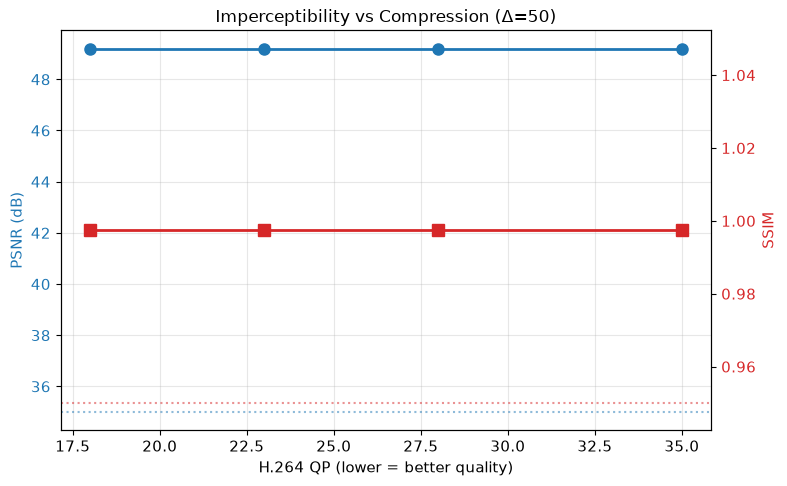

✓ Saved: figure_psnr_ssim.png


In [12]:
# ── Figure 1: PSNR & SSIM vs QP ─────────────────────────────────────
if qp_results:
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    qps = [r['qp'] for r in qp_results if r.get('avg_psnr') is not None]
    psnrs = [r['avg_psnr'] for r in qp_results if r.get('avg_psnr') is not None]
    ssims = [r['avg_ssim'] for r in qp_results if r.get('avg_ssim') is not None]
    
    color1 = 'tab:blue'
    ax1.set_xlabel('H.264 QP (lower = better quality)')
    ax1.set_ylabel('PSNR (dB)', color=color1)
    ax1.plot(qps, psnrs, 'o-', color=color1, linewidth=2, markersize=8, label='PSNR')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.axhline(35, color=color1, linestyle=':', alpha=0.5, label='PSNR threshold (35 dB)')
    ax1.grid(True, alpha=0.3)
    
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel('SSIM', color=color2)
    ax2.plot(qps, ssims, 's-', color=color2, linewidth=2, markersize=8, label='SSIM')
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.axhline(0.95, color=color2, linestyle=':', alpha=0.5)
    
    plt.title(f'Imperceptibility vs Compression (Δ={QIM_DELTA})', fontsize=12)
    fig.tight_layout()
    plt.savefig(FIG_PSNR_SSIM, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {FIG_PSNR_SSIM}")

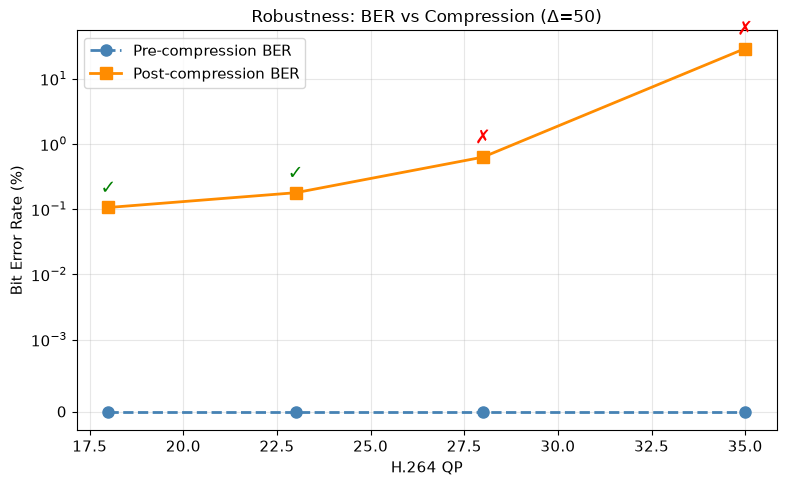

✓ Saved: figure_ber_vs_qp.png


In [13]:
# ── Figure 2: BER vs QP ─────────────────────────────────────────────
if qp_results:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    qps        = [r['qp']       for r in qp_results if r.get('post_ber') is not None]
    pre_bers   = [r['pre_ber']  for r in qp_results if r.get('post_ber') is not None]
    post_bers  = [r['post_ber'] for r in qp_results if r.get('post_ber') is not None]
    decrypts   = [r['decryption_ok'] for r in qp_results if r.get('post_ber') is not None]
    
    ax.plot(qps, pre_bers,  'o--', label='Pre-compression BER',  linewidth=2,
            markersize=8, color='steelblue')
    ax.plot(qps, post_bers, 's-',  label='Post-compression BER', linewidth=2,
            markersize=8, color='darkorange')
    
    # Annotate decryption result at each point
    for c, b, ok in zip(qps, post_bers, decrypts):
        sym = '✓' if ok else '✗'
        col = 'green' if ok else 'red'
        ax.annotate(sym, (c, b), textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=14, color=col, fontweight='bold')
    
    ax.set_xlabel('H.264 QP')
    ax.set_ylabel('Bit Error Rate (%)')
    ax.set_title(f'Robustness: BER vs Compression (Δ={QIM_DELTA})', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('symlog', linthresh=0.001)
    
    plt.tight_layout()
    plt.savefig(FIG_BER_VS_QP, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {FIG_BER_VS_QP}")

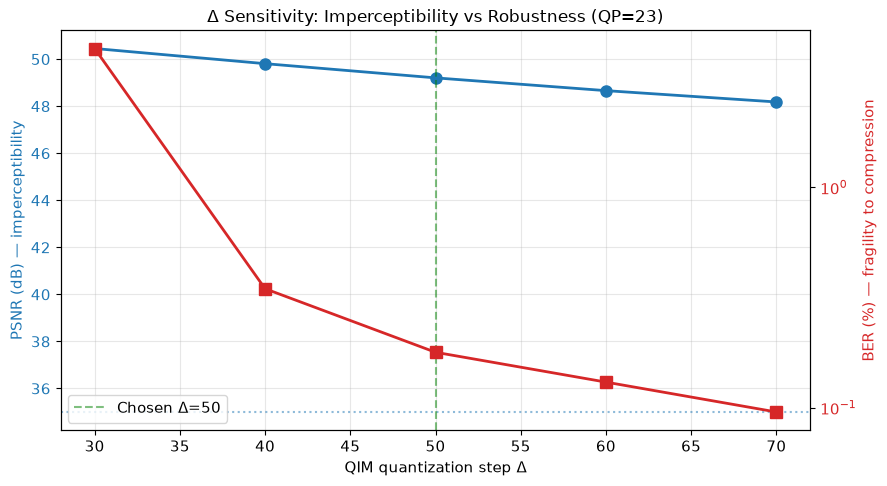

✓ Saved: figure_delta_sweep.png


In [14]:
# ── Figure 3: Δ sensitivity (PSNR vs BER trade-off) ──────────────────
if delta_results:
    fig, ax1 = plt.subplots(figsize=(9, 5))
    
    deltas = [r['delta']    for r in delta_results if r.get('post_ber') is not None]
    psnrs  = [r['avg_psnr'] for r in delta_results if r.get('post_ber') is not None]
    bers   = [r['post_ber'] for r in delta_results if r.get('post_ber') is not None]
    decryp = [r['decryption_ok'] for r in delta_results if r.get('post_ber') is not None]
    
    color1 = 'tab:blue'
    ax1.set_xlabel('QIM quantization step Δ')
    ax1.set_ylabel('PSNR (dB) — imperceptibility', color=color1)
    ax1.plot(deltas, psnrs, 'o-', color=color1, linewidth=2, markersize=8)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(35, color=color1, linestyle=':', alpha=0.5)
    
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel('BER (%) — fragility to compression', color=color2)
    ax2.plot(deltas, bers, 's-', color=color2, linewidth=2, markersize=8)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_yscale('symlog', linthresh=0.001)
    
    # Highlight the chosen Δ
    if QIM_DELTA in deltas:
        idx = deltas.index(QIM_DELTA)
        ax1.axvline(QIM_DELTA, color='green', linestyle='--', alpha=0.5,
                    label=f'Chosen Δ={QIM_DELTA}')
        ax1.legend(loc='lower left')
    
    plt.title('Δ Sensitivity: Imperceptibility vs Robustness (QP=23)', fontsize=12)
    fig.tight_layout()
    plt.savefig(FIG_DELTA_SWEEP, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {FIG_DELTA_SWEEP}")

Generating visual quality grid...


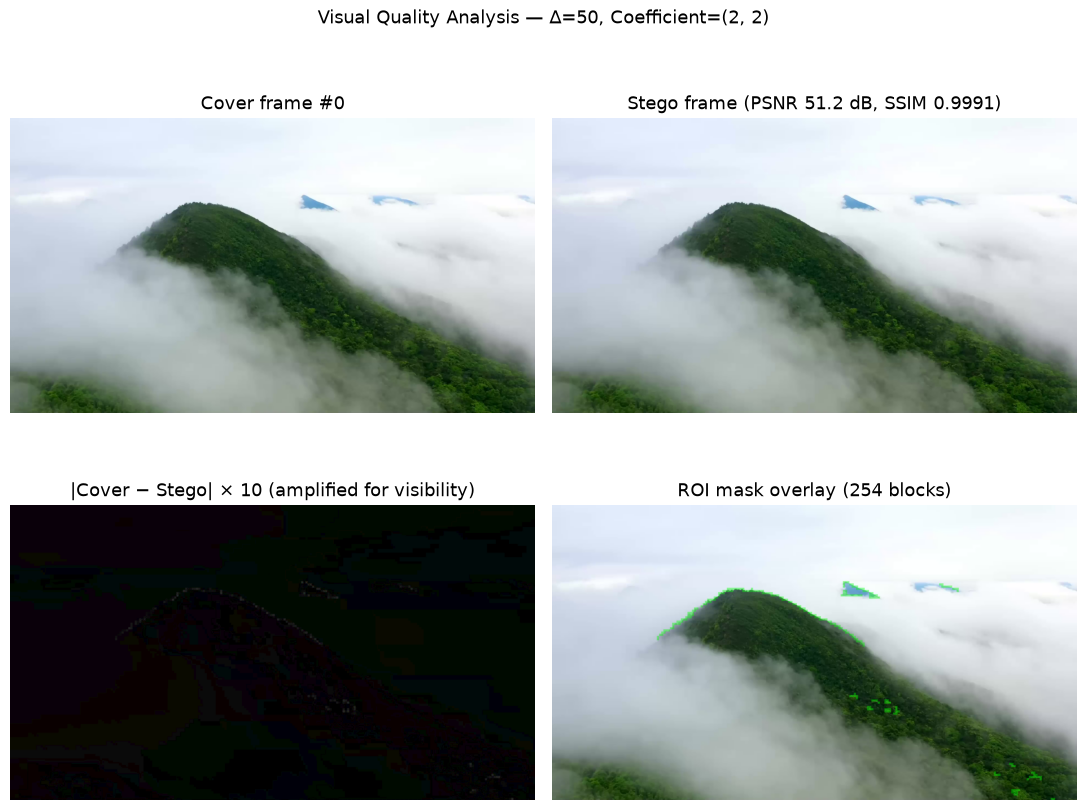

✓ Saved: figure_quality_grid.png


In [15]:
# ── Figure 4: Visual cover-vs-stego comparison at baseline ───────────
# Re-embed at default Δ to grab a stego frame for visualization
print("Generating visual quality grid...")

stego_demo = []
bit_idx = 0
for i, frame in enumerate(cover_frames[:5]):
    if bit_idx >= len(payload_bits):
        stego_demo.append(frame.copy())
        continue
    sf, bit_idx, _ = embed_in_frame(
        frame, roi_masks[i], payload_bits, bit_idx,
        BLOCK_SIZE, COEFF_POS, QIM_DELTA
    )
    stego_demo.append(sf)

# Pick the first modified frame
demo_idx = 0
cover_demo = cover_frames[demo_idx]
sf_demo    = stego_demo[demo_idx]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].imshow(cv2.cvtColor(cover_demo, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f'Cover frame #{demo_idx}')
axes[0, 0].axis('off')

p = calculate_psnr(cover_demo, sf_demo)
s = calculate_ssim(cover_demo, sf_demo)
axes[0, 1].imshow(cv2.cvtColor(sf_demo, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f'Stego frame (PSNR {p:.1f} dB, SSIM {s:.4f})')
axes[0, 1].axis('off')

# Difference map (10× amplified)
diff = np.abs(cover_demo.astype(np.float64) - sf_demo.astype(np.float64))
diff_amp = np.clip(diff * 10, 0, 255).astype(np.uint8)
axes[1, 0].imshow(cv2.cvtColor(diff_amp, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('|Cover − Stego| × 10 (amplified for visibility)')
axes[1, 0].axis('off')

# ROI mask overlay
mask_vis = cover_demo.copy()
mask_pixel = np.repeat(np.repeat(roi_masks[demo_idx], BLOCK_SIZE, axis=0),
                       BLOCK_SIZE, axis=1)
mask_pixel = mask_pixel[:cover_demo.shape[0], :cover_demo.shape[1]]
overlay = mask_vis.copy()
overlay[mask_pixel == 1] = (0, 255, 0)
mask_vis = cv2.addWeighted(mask_vis, 0.6, overlay, 0.4, 0)
axes[1, 1].imshow(cv2.cvtColor(mask_vis, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'ROI mask overlay ({int(np.sum(roi_masks[demo_idx]))} blocks)')
axes[1, 1].axis('off')

plt.suptitle(f'Visual Quality Analysis — Δ={QIM_DELTA}, Coefficient={COEFF_POS}',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIG_QUALITY_GRID, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {FIG_QUALITY_GRID}")

## Section 11: Capacity Analysis

How much data can the QVSC pipeline carry per frame? This depends on:
- Frame resolution (more pixels → more 8×8 blocks)
- ROI edge_threshold (lower → more blocks marked, more capacity)
- Number of frames

We compute the theoretical and actual capacity for the current cover
video at several edge_threshold values.

Sweeping ROI edge_threshold...
  threshold=0.10 →   353 ROI blocks/frame (   44 B/frame,  18753 B/video)
  threshold=0.20 →   298 ROI blocks/frame (   37 B/frame,  15831 B/video)
  threshold=0.30 →   254 ROI blocks/frame (   31 B/frame,  13493 B/video)
  threshold=0.40 →   215 ROI blocks/frame (   26 B/frame,  11421 B/video)
  threshold=0.50 →   181 ROI blocks/frame (   22 B/frame,   9615 B/video)
  threshold=0.60 →   152 ROI blocks/frame (   19 B/frame,   8075 B/video)


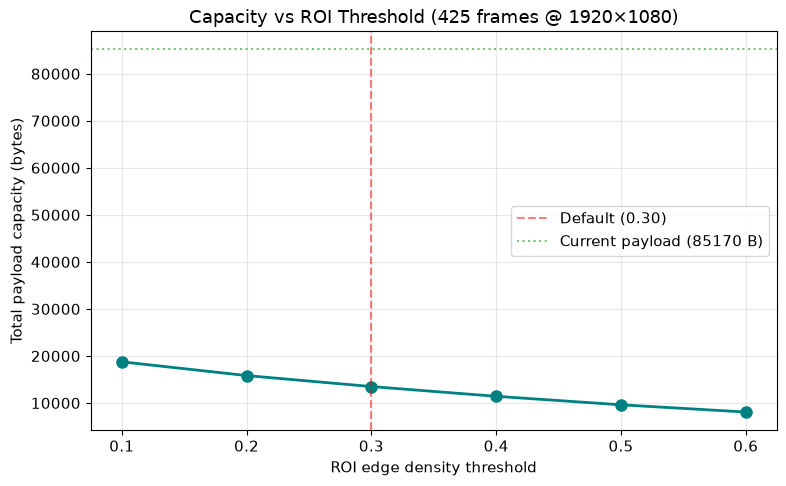


✓ Saved: figure_capacity.png


In [16]:
# ── Capacity vs edge_threshold ────────────────────────────────────────
edge_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
capacity_data   = []

print("Sweeping ROI edge_threshold...")
for th in edge_thresholds:
    # Re-detect ROI on first frame at this threshold
    sample_mask = detect_roi_blocks(cover_frames[0], edge_threshold=th)
    blocks_per_frame   = int(np.sum(sample_mask))
    bits_per_frame     = blocks_per_frame  # 1 bit per ROI block
    bytes_per_frame    = bits_per_frame // 8
    bits_per_video     = bits_per_frame * len(cover_frames)
    bytes_per_video    = bits_per_video // 8
    
    capacity_data.append({
        'edge_threshold':  th,
        'roi_blocks':      blocks_per_frame,
        'bits_per_frame':  bits_per_frame,
        'bytes_per_frame': bytes_per_frame,
        'bytes_per_video': bytes_per_video
    })
    print(f"  threshold={th:.2f} → {blocks_per_frame:5d} ROI blocks/frame "
          f"({bytes_per_frame:5d} B/frame, {bytes_per_video:6d} B/video)")

cap_df = pd.DataFrame(capacity_data)

# ── Plot capacity vs threshold ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cap_df['edge_threshold'], cap_df['bytes_per_video'],
        'o-', linewidth=2, markersize=8, color='teal')
ax.set_xlabel('ROI edge density threshold')
ax.set_ylabel('Total payload capacity (bytes)')
ax.set_title(f'Capacity vs ROI Threshold ({len(cover_frames)} frames @ {w}×{h})')
ax.grid(True, alpha=0.3)
ax.axvline(0.30, color='red', linestyle='--', alpha=0.5, label='Default (0.30)')
ax.axhline(len(ciphertext_blob), color='green', linestyle=':', alpha=0.5,
           label=f'Current payload ({len(ciphertext_blob)} B)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_CAPACITY, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {FIG_CAPACITY}")

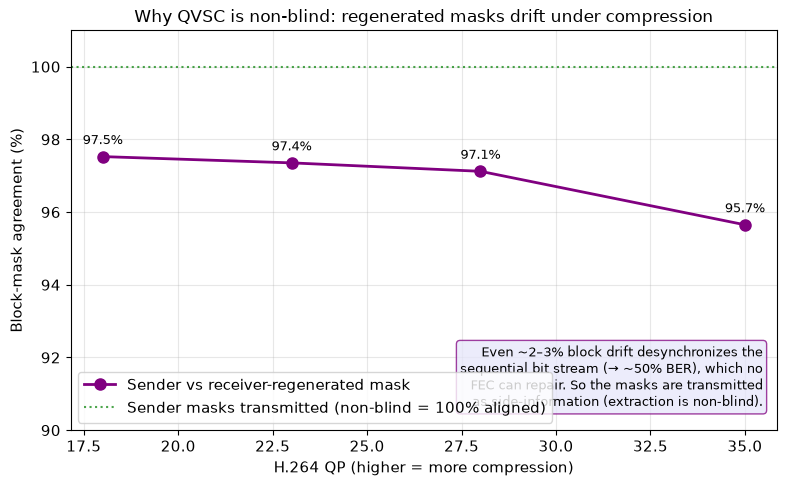

✓ Saved: figure_mask_agreement.png


In [17]:
# ── Figure 5: Mask agreement vs QP — why QVSC must be non-blind ──────
# Diagnostic figure. Extraction uses the sender's transmitted masks, so this
# curve does NOT affect BER; it quantifies how far receiver-regenerated masks
# drift under compression. Any drift below 100% would desynchronize the
# sequential bit stream — which is exactly why the masks are side-information.
if qp_results:
    qa = [r for r in qp_results if r.get('mask_agreement') is not None]
    if qa:
        fig, ax = plt.subplots(figsize=(8, 5))
        qps   = [r['qp'] for r in qa]
        agree = [r['mask_agreement'] for r in qa]

        ax.plot(qps, agree, 'o-', color='purple', linewidth=2, markersize=8,
                label='Sender vs receiver-regenerated mask')
        ax.axhline(100, color='green', linestyle=':', alpha=0.7,
                   label='Sender masks transmitted (non-blind = 100% aligned)')
        for x, y in zip(qps, agree):
            ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                        xytext=(0, 9), ha='center', fontsize=9)

        lo = min(90.0, min(agree) - 2)
        ax.set_ylim(lo, 101)
        ax.set_xlabel('H.264 QP (higher = more compression)')
        ax.set_ylabel('Block-mask agreement (%)')
        ax.set_title('Why QVSC is non-blind: regenerated masks drift under compression',
                     fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='lower left')
        ax.text(0.98, 0.05,
                'Even ~2–3% block drift desynchronizes the\n'
                'sequential bit stream (→ ~50% BER), which no\n'
                'FEC can repair. So the masks are transmitted\n'
                'as side-information (extraction is non-blind).',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
                bbox=dict(boxstyle='round', fc='lavender', ec='purple', alpha=0.75))

        plt.tight_layout()
        plt.savefig(FIG_MASK_AGREE, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: {FIG_MASK_AGREE}")
    else:
        print("  No mask-agreement data to plot.")


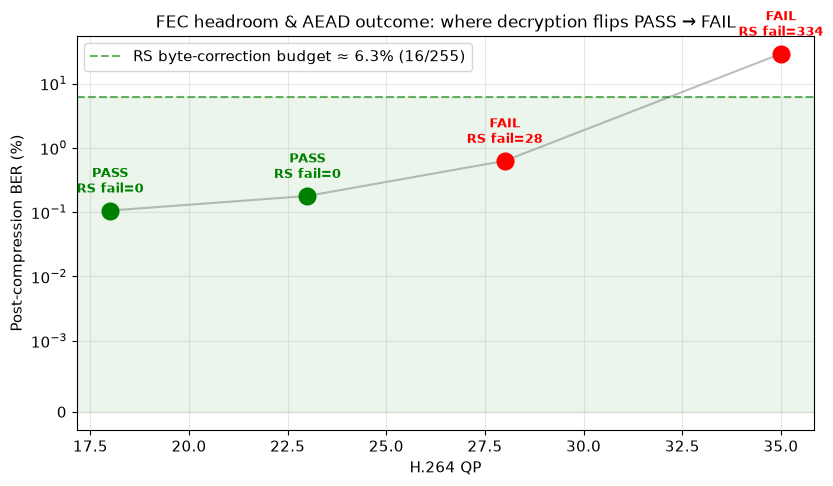

✓ Saved: figure_fec_headroom.png


In [18]:
# ── Figure 6: FEC headroom & AEAD outcome vs QP ─────────────────────
# The headline "failure point" diagnostic. Post-compression BER is plotted
# per QP; each point is coloured by the true success criterion (ChaCha20-
# Poly1305 PASS/FAIL) and annotated with the number of Reed–Solomon codewords
# that failed to correct. The shaded band is the RS per-codeword byte-error
# budget (t = (N−K)/2 = 16 of 255 bytes ≈ 6.3%); interleaving spreads bursts
# across codewords, so it is a guide, not a hard bit-level threshold.
if qp_results:
    qf = [r for r in qp_results if r.get('post_ber') is not None]
    if qf:
        budget_pct = (fec.RS_PARITY / 2) / fec.RS_N * 100.0   # ≈ 6.27 %

        fig, ax = plt.subplots(figsize=(8.5, 5))
        qps   = [r['qp'] for r in qf]
        pbers = [max(r['post_ber'], 1e-4) for r in qf]   # clamp for symlog
        oks   = [r['decryption_ok'] for r in qf]
        fails = [r.get('fec_fails') for r in qf]

        ax.axhspan(0, budget_pct, color='green', alpha=0.08)
        ax.axhline(budget_pct, color='green', linestyle='--', alpha=0.6,
                   label=f'RS byte-correction budget ≈ {budget_pct:.1f}% (16/255)')
        ax.plot(qps, pbers, '-', color='gray', alpha=0.5, zorder=0)

        for x, y, ok, fl in zip(qps, pbers, oks, fails):
            col = 'green' if ok else 'red'
            ax.plot(x, y, 'o', color=col, markersize=12, zorder=3)
            lab = 'PASS' if ok else 'FAIL'
            if fl is not None:
                lab += f'\nRS fail={fl}'
            ax.annotate(lab, (x, y), textcoords='offset points', xytext=(0, 13),
                        ha='center', fontsize=9, color=col, fontweight='bold')

        ax.set_yscale('symlog', linthresh=1e-3)
        ax.set_xlabel('H.264 QP')
        ax.set_ylabel('Post-compression BER (%)')
        ax.set_title('FEC headroom & AEAD outcome: where decryption flips PASS → FAIL',
                     fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')

        plt.tight_layout()
        plt.savefig(FIG_FEC_HEADROOM, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: {FIG_FEC_HEADROOM}")
    else:
        print("  No post-compression BER data to plot.")


## Section 12: Generate Markdown Table for the Thesis Document

Produces a copy-paste ready table for the LaTeX/Word thesis Results
section. Pandas → Markdown handles the formatting; we just curate
the columns that matter for the headline result.

In [21]:
# ── Headline table: QP sweep (the main thesis result) ───────────────
qp_only = df[df['experiment'] == 'QP sweep'].copy()

if not qp_only.empty:
    table_md = "## QVSC Headline Results — QP Sweep\n\n"
    table_md += f"**Configuration:** Δ={QIM_DELTA}, "
    table_md += f"Coefficient position={COEFF_POS}, "
    table_md += f"Block size={BLOCK_SIZE}×{BLOCK_SIZE}, "
    table_md += f"Resolution={w}x{h}, "
    table_md += f"Frames={len(cover_frames)}, "
    table_md += f"Payload={len(ciphertext_blob)} B\n\n"
    
    table_md += "| QP | PSNR (dB) | SSIM | Pre-comp BER (%) | Post-comp BER (%) | Mask Agreement (%) | Decryption |\n"
    table_md += "|-----|-----------|------|------------------|-------------------|--------------------|-----------|\n"
    
    for _, row in qp_only.sort_values('qp').iterrows():
        table_md += f"| {int(row['qp'])} "
        table_md += f"| {row['psnr_db']:.2f} "
        table_md += f"| {row['ssim']:.4f} "
        table_md += f"| {row['pre_ber_%']:.4f} "
        table_md += f"| {row['post_ber_%']:.4f} "
        table_md += f"| {row['mask_agree_%']:.2f} "
        table_md += f"| {row['decryption']} |\n"
    
    # Δ sweep table
    delta_only = df[df['experiment'] == 'Δ sweep'].copy()
    if not delta_only.empty:
        table_md += "\n## Δ Sensitivity (QP=23)\n\n"
        table_md += "| Δ | PSNR (dB) | SSIM | Post-comp BER (%) | Decryption |\n"
        table_md += "|---|-----------|------|-------------------|-----------|\n"
        
        for _, row in delta_only.sort_values('delta').iterrows():
            table_md += f"| {int(row['delta'])} "
            table_md += f"| {row['psnr_db']:.2f} "
            table_md += f"| {row['ssim']:.4f} "
            table_md += f"| {row['post_ber_%']:.4f} "
            table_md += f"| {row['decryption']} |\n"
    
    # Capacity table
    table_md += "\n## Payload Capacity vs ROI Threshold\n\n"
    table_md += "| Edge Threshold | ROI Blocks/Frame | Bytes/Frame | Total Payload (B) |\n"
    table_md += "|----------------|------------------|-------------|-------------------|\n"
    for r in capacity_data:
        table_md += f"| {r['edge_threshold']:.2f} "
        table_md += f"| {r['roi_blocks']} "
        table_md += f"| {r['bytes_per_frame']} "
        table_md += f"| {r['bytes_per_video']} |\n"
    
    with open(RESULTS_MD, 'w', encoding='utf-8') as f:
        f.write(table_md)
    
    print(f"✓ Markdown saved: {RESULTS_MD}")
    print()
    print("="*70)
    print("  THESIS-READY TABLE (preview)")
    print("="*70)
    print(table_md)
else:
    print("  No QP sweep data — run with RUN_FULL_SWEEP=True first.")

✓ Markdown saved: thesis_results_table.md

  THESIS-READY TABLE (preview)
## QVSC Headline Results — QP Sweep

**Configuration:** Δ=50, Coefficient position=(2, 2), Block size=8×8, Resolution=1920x1080, Frames=425, Payload=85170 B

| QP | PSNR (dB) | SSIM | Pre-comp BER (%) | Post-comp BER (%) | Mask Agreement (%) | Decryption |
|-----|-----------|------|------------------|-------------------|--------------------|-----------|
| 18 | 49.20 | 0.9974 | 0.0000 | 0.1060 | 97.53 | PASS |
| 23 | 49.20 | 0.9974 | 0.0000 | 0.1786 | 97.35 | PASS |
| 28 | 49.20 | 0.9974 | 0.0000 | 0.6274 | 97.12 | FAIL |
| 35 | 49.20 | 0.9974 | 0.0000 | 29.0719 | 95.65 | FAIL |

## Δ Sensitivity (QP=23)

| Δ | PSNR (dB) | SSIM | Post-comp BER (%) | Decryption |
|---|-----------|------|-------------------|-----------|
| 30 | 50.45 | 0.9983 | 4.2693 | FAIL |
| 40 | 49.81 | 0.9979 | 0.3470 | PASS |
| 50 | 49.20 | 0.9974 | 0.1786 | PASS |
| 60 | 48.66 | 0.9969 | 0.1308 | PASS |
| 70 | 48.18 | 0.9964 | 0.0957 | PASS |

In [22]:
# ── Headline table: QP sweep (the main thesis result) ───────────────

qp_only = df[df['experiment'] == 'QP sweep'].copy()

if not qp_only.empty:

    table_md = "## QVSC Headline Results — QP Sweep\n\n"

    table_md += f"**Configuration:** Δ={QIM_DELTA}, "
    table_md += f"Coefficient position={COEFF_POS}, "
    table_md += f"Block size={BLOCK_SIZE}×{BLOCK_SIZE}, "
    table_md += f"Resolution={w}×{h}, "
    table_md += f"Frames={len(cover_frames)}, "
    table_md += f"Payload={len(ciphertext_blob)} B\n\n"


    # QP sweep table
    table_md += (
        "| QP | PSNR (dB) | SSIM | Pre-comp BER (%) "
        "| Post-comp BER (%) | Mask Agreement (%) | FEC Failures | Decryption |\n"
    )

    table_md += (
        "|-----|-----------|------|------------------|"
        "-------------------|--------------------|--------------|------------|\n"
    )


    for _, row in qp_only.sort_values('qp').iterrows():

        table_md += (
            f"| {int(row['qp'])} "
            f"| {row['psnr_db']:.2f} "
            f"| {row['ssim']:.4f} "
            f"| {row['pre_ber_%']:.4f} "
            f"| {row['post_ber_%']:.4f} "
            f"| {row['mask_agree_%']:.2f} "
            f"| {int(row['fec_fails']) if 'fec_fails' in row else 'N/A'} "
            f"| {row['decryption']} |\n"
        )


    # ── Delta sensitivity table ─────────────────────────────

    delta_only = df[df['experiment'] == 'Δ sweep'].copy()

    if not delta_only.empty:

        table_md += "\n## Δ Sensitivity (QP=23)\n\n"

        table_md += (
            "| Δ | PSNR (dB) | SSIM | "
            "Post-comp BER (%) | Decryption |\n"
        )

        table_md += (
            "|---|-----------|------|"
            "-------------------|------------|\n"
        )


        for _, row in delta_only.sort_values('delta').iterrows():

            table_md += (
                f"| {int(row['delta'])} "
                f"| {row['psnr_db']:.2f} "
                f"| {row['ssim']:.4f} "
                f"| {row['post_ber_%']:.4f} "
                f"| {row['decryption']} |\n"
            )


    # ── Capacity table ──────────────────────────────────────

    table_md += "\n## Payload Capacity vs ROI Threshold\n\n"

    table_md += (
        "| Edge Threshold | ROI Blocks/Frame | "
        "Bytes/Frame | Total Payload (B) |\n"
    )

    table_md += (
        "|----------------|------------------|"
        "-------------|-------------------|\n"
    )


    for r in capacity_data:

        table_md += (
            f"| {r['edge_threshold']:.2f} "
            f"| {r['roi_blocks']} "
            f"| {r['bytes_per_frame']} "
            f"| {r['bytes_per_video']} |\n"
        )


    # ── SAVE USING UTF-8 ────────────────────────────────────

    with open(RESULTS_MD, 'w', encoding='utf-8') as f:
        f.write(table_md)


    print(f"✓ Markdown saved: {RESULTS_MD}")
    print()

    print("="*70)
    print("  THESIS-READY TABLE (preview)")
    print("="*70)

    print(table_md)


else:

    print("No QP sweep data — run with RUN_FULL_SWEEP=True first.")

✓ Markdown saved: thesis_results_table.md

  THESIS-READY TABLE (preview)
## QVSC Headline Results — QP Sweep

**Configuration:** Δ=50, Coefficient position=(2, 2), Block size=8×8, Resolution=1920×1080, Frames=425, Payload=85170 B

| QP | PSNR (dB) | SSIM | Pre-comp BER (%) | Post-comp BER (%) | Mask Agreement (%) | FEC Failures | Decryption |
|-----|-----------|------|------------------|-------------------|--------------------|--------------|------------|
| 18 | 49.20 | 0.9974 | 0.0000 | 0.1060 | 97.53 | 0 | PASS |
| 23 | 49.20 | 0.9974 | 0.0000 | 0.1786 | 97.35 | 0 | PASS |
| 28 | 49.20 | 0.9974 | 0.0000 | 0.6274 | 97.12 | 28 | FAIL |
| 35 | 49.20 | 0.9974 | 0.0000 | 29.0719 | 95.65 | 334 | FAIL |

## Δ Sensitivity (QP=23)

| Δ | PSNR (dB) | SSIM | Post-comp BER (%) | Decryption |
|---|-----------|------|-------------------|------------|
| 30 | 50.45 | 0.9983 | 4.2693 | FAIL |
| 40 | 49.81 | 0.9979 | 0.3470 | PASS |
| 50 | 49.20 | 0.9974 | 0.1786 | PASS |
| 60 | 48.66 | 0.9969 | 0.13

## Section 13: Summary

### Module 7 — Quality Benchmarking — Complete

This module produced the quantitative evidence backing the QVSC thesis
claims. The full pipeline (Modules 1–6) has now been benchmarked across
compression strengths (QP), embedding strengths (Δ), and capacity settings.

### What was generated

| File | Content |
|------|---------|
| `benchmark_results.csv`     | Full results table (every run) |
| `benchmark_results.npy`     | NumPy dict with all raw data |
| `thesis_results_table.md`   | Markdown tables ready to paste into thesis |
| `figure_psnr_ssim.png`      | Imperceptibility vs QP curve |
| `figure_ber_vs_qp.png`      | Robustness curve (headline figure) |
| `figure_delta_sweep.png`    | Δ trade-off justifying the Δ=50 choice |
| `figure_quality_grid.png`   | Visual cover-vs-stego comparison |
| `figure_capacity.png`       | Payload capacity vs ROI threshold |
| `figure_mask_agreement.png` | Mask drift vs QP (justifies non-blind design) |
| `figure_fec_headroom.png`   | FEC headroom & where decryption fails |

### Pipeline status

```
[M1] E91 QKD → 256-bit key                        ✓ DONE
[M2] ChaCha20-Poly1305 encryption                 ✓ DONE
[FEC] Reed–Solomon + interleaving wrap            ✓ DONE
[M3] Canny ROI detection                          ✓ DONE
[M4] DCT-QIM embedding (Y, informed) + QP H.264   ✓ DONE
[M5] DCT-QIM extraction (sender masks)            ✓ DONE
[M6] FEC decode → ChaCha20-Poly1305 verify        ✓ DONE
[M7] PSNR / SSIM / BER benchmarking + figures     ✓ DONE  ← (this notebook)
```

### Honest description of the design (for the write-up)

- **Compression axis is QP, not CRF.** Constant QP quantizes every frame
  identically; CRF's per-frame rate control destroyed the payload on all
  frames after the first. Report robustness against QP.
- **Embedding is in the Y (luminance) channel** at low-frequency DCT
  coefficient (2,2), Δ=50, with *informed* embedding to make the
  pre-compression channel bit-exact.
- **The system is NON-BLIND.** Extraction uses the sender's ROI masks
  (`roi_masks.npy`) as transmitted side-information. Receiver-side
  regeneration was measured at only ~97% block agreement, and because
  bits are packed sequentially into ROI blocks, even that small drift
  desynchronizes the stream (~50% BER). The mask-agreement number is
  reported as a *diagnostic* that motivates transmitting the masks —
  not as the extraction method. Do **not** describe the system as blind.
- **FEC is what makes AEAD viable.** Lossy compression leaves a small
  residual BER (~0.2% at QP 23); ChaCha20-Poly1305 rejects any single-bit
  error, so Reed–Solomon (+interleaving) corrects the residual to deliver
  a byte-exact ciphertext. Decryption PASS is the true success criterion.

### What's left for the thesis

1. **Run the QP sweep up into the 40s** to find the exact QP where FEC
   first fails (decryption flips PASS → FAIL). That failure point is a
   strong empirical-limit result. Optionally add an interleaving ablation
   (sweep with vs without interleaving) to show it shifts the failure QP.

2. **Pull numbers into the Results section.** The QP table is the headline;
   the Δ sensitivity table justifies Δ=50; the capacity table answers
   "how much data can we hide".

3. **Compare against QSAC (Elsevier 2025)** — side-by-side of the metrics
   both works report, positioning QVSC as the video extension of QSAC.

4. **Future work.** Per scope: video-in-video payload; audio synchronization
   (full A/V with QSAC); adaptive Δ per frame; multi-coefficient embedding;
   and a desynchronization-resistant scheme to recover *blind* extraction.

### Headline talking point for supervisor

> "The QVSC pipeline recovers the ciphertext byte-exact (AEAD verification
> PASS) through constant-QP H.264 compression up to QP 23, where the raw
> channel BER (~0.2%) is corrected to zero by a Reed–Solomon FEC layer,
> at ≥48 dB PSNR and ≥0.99 SSIM. It extends the QSAC framework from audio
> to video, adding compression resilience via Y-channel DCT-QIM, informed
> embedding, adaptive ROI masking, and forward error correction. ROI masks
> are transmitted as side-information (the system is non-blind)."

You're done with the implementation. Time to write — using the descriptions above so the prose matches the code.